<a href="https://colab.research.google.com/github/gcoelho3008/classification_neural_network/blob/main/classificacao_rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vsão computacional com rede neural

### Extração de todos os pixels da imagem


In [85]:
import cv2
import numpy as np
import os
import zipfile
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab.patches import cv2_imshow
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Extração dos pixels das imagens

In [39]:
path = '/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Datasets/homer_bart_1.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [40]:
diretorio = '/content/homer_bart_1'
arquivos = [os.path.join(diretorio, f) for f in sorted(os.listdir(diretorio))]
print(arquivos)

['/content/homer_bart_1/.DS_Store', '/content/homer_bart_1/bart1.bmp', '/content/homer_bart_1/bart10.bmp', '/content/homer_bart_1/bart100.bmp', '/content/homer_bart_1/bart101.bmp', '/content/homer_bart_1/bart102.bmp', '/content/homer_bart_1/bart103.bmp', '/content/homer_bart_1/bart104.bmp', '/content/homer_bart_1/bart105.bmp', '/content/homer_bart_1/bart106.bmp', '/content/homer_bart_1/bart108.bmp', '/content/homer_bart_1/bart109.bmp', '/content/homer_bart_1/bart11.bmp', '/content/homer_bart_1/bart110.bmp', '/content/homer_bart_1/bart111.bmp', '/content/homer_bart_1/bart112.bmp', '/content/homer_bart_1/bart113.bmp', '/content/homer_bart_1/bart114.bmp', '/content/homer_bart_1/bart115.bmp', '/content/homer_bart_1/bart116.bmp', '/content/homer_bart_1/bart117.bmp', '/content/homer_bart_1/bart118.bmp', '/content/homer_bart_1/bart119.bmp', '/content/homer_bart_1/bart12.bmp', '/content/homer_bart_1/bart120.bmp', '/content/homer_bart_1/bart121.bmp', '/content/homer_bart_1/bart122.bmp', '/conte

In [41]:
type(arquivos)

list

In [42]:
largura, altura = 128, 128

In [43]:
imagens = []
classes = []

In [ ]:
for imagem_caminho in arquivos:
  #print(imagem_caminho)
  try:
    imagem = cv2.imread(imagem_caminho)
    (H, W) = imagem.shape[:2]
  except:
    continue

  imagem = cv2.resize(imagem, (largura, altura))
  imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
  cv2_imshow(imagem)

  #transforma matriz para vetor
  imagem = imagem.ravel()
  #print(imagem.shape)

  imagens.append(imagem)
  nome_imagem = os.path.basename(os.path.normpath(imagem_caminho))
  #print(nome_imagem)

  if nome_imagem.startswith('b'):
    classe = 0
  else:
    classe = 1

  classes.append(classe)
  #print(classe)



In [ ]:
imagens

In [46]:
print(classes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [47]:
imagens[100], classes[100]

(array([255, 255, 255, ..., 255, 255, 255], dtype=uint8), 0)

In [48]:
imagens[200], classes[200]

(array([255, 255, 255, ..., 255, 255, 255], dtype=uint8), 1)

In [49]:
type(imagens), type(classes)

(list, list)

In [50]:
# Previsores(pixels)
X = np.asarray(imagens)

# Respostas
y = np.asarray(classes)

In [51]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [52]:
X.shape, y.shape

((269, 16384), (269,))

In [55]:
print(y[:20])
print(type(y[0]))
print(np.unique(y))
print(len(np.unique(y)))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
<class 'numpy.int64'>
[0 1]
2


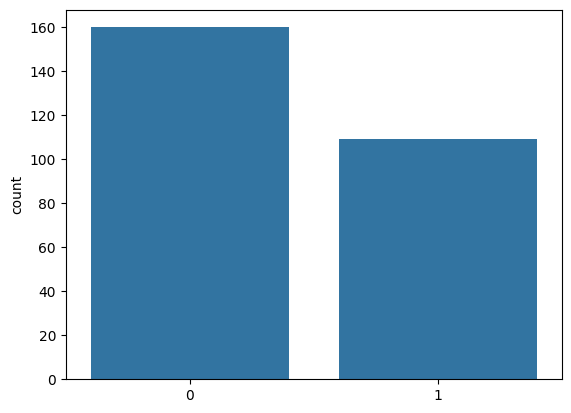

In [57]:
sns.countplot(x=y);

In [58]:
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

### Normalização dos dados
Transformar escala de 0 a255 para 0 a1

In [59]:
X[0].max(), X[0].min

(np.uint8(255), <function ndarray.min>)

In [61]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [62]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [63]:
X[1]

array([0.9947644 , 0.99479167, 0.99479167, ..., 0.99559471, 0.99595142,
       0.9950495 ])

### Base de Treino e Teste

In [64]:
X.shape

(269, 16384)

In [66]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state =1)

In [67]:
X_treinamento.shape, y_treinamento.shape

((215, 16384), (215,))

In [68]:
X_teste.shape, y_teste.shape

((54, 16384), (54,))

### Construção e Treinamento de uma rede Neural

In [69]:
128 * 128

16384

In [70]:
(16384 + 2) / 2

8193.0

In [72]:
network1 = tf.keras.models.Sequential()
network1.add(tf.keras.layers.Dense(input_shape = (16384,), units = 8193, activation = 'relu' ))
network1.add(tf.keras.layers.Dense(units = 8193, activation = 'relu'))
network1.add(tf.keras.layers.Dense(units = 8193, activation = 'relu'))
network1.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

In [73]:
network1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,517,383 (1.00 GB)

 Trainable params: 268,517,383 (1.00 GB)

 Non-trainable params: 0 (0.00 B)

In [74]:
network1.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [75]:
historico = network1.fit(X_treinamento, y_treinamento, epochs = 50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.5023 - loss: 371.9427
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.5302 - loss: 12.4882
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 78s 5s/step - accuracy: 0.5349 - loss: 3.1424
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.5488 - loss: 0.7184
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.5209 - loss: 0.7584
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.5767 - loss: 0.7047
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.6186 - loss: 0.6694
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5953 - loss: 0.6723
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.5349 - loss: 0.6911
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.6233 - loss: 0.6579
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6465 - loss: 0.6346
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.7070 - loss: 0.5687
Epoch 13/5

### Avaliação da rede neural

In [76]:
historico.history.keys()

dict_keys(['accuracy', 'loss'])

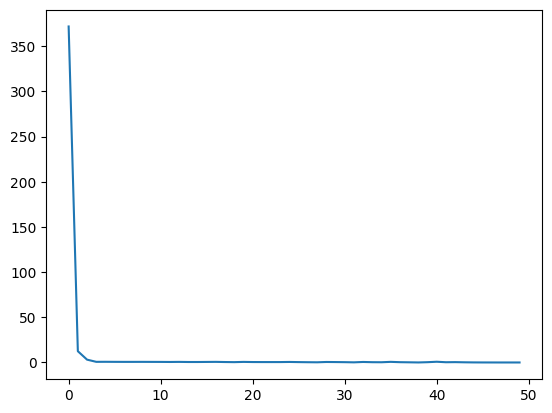

In [78]:
plt.plot(historico.history['loss'])

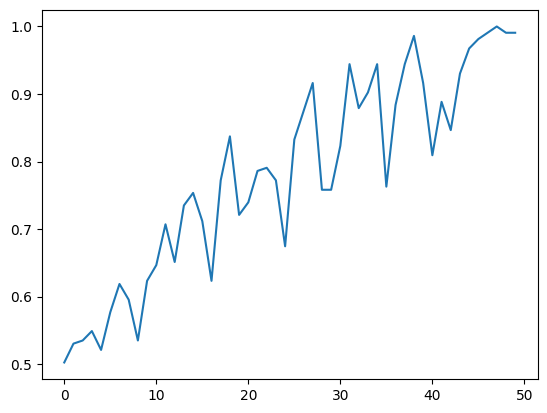

In [79]:
plt.plot(historico.history['accuracy'])

In [80]:
X_teste.shape

(54, 16384)

In [81]:
previsoes = network1.predict(X_teste)
previsoes

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step


array([[1.1214897e-06],
       [9.7254550e-01],
       [2.6316707e-06],
       [2.9193420e-06],
       [9.2965993e-04],
       [2.1208875e-06],
       [9.9580139e-01],
       [4.3721478e-03],
       [2.0377542e-04],
       [1.0485458e-04],
       [3.6181925e-06],
       [9.9999952e-01],
       [3.9933613e-03],
       [9.2933609e-05],
       [7.5652338e-06],
       [2.4883107e-06],
       [7.0644652e-05],
       [3.6206926e-05],
       [1.0259049e-05],
       [9.1381497e-07],
       [3.7084274e-06],
       [1.5478830e-04],
       [7.4538016e-06],
       [1.4814756e-05],
       [1.0431939e-05],
       [8.4361658e-05],
       [2.9103439e-06],
       [4.9257390e-03],
       [1.9969615e-05],
       [2.1407998e-01],
       [4.2617128e-05],
       [9.9592584e-01],
       [9.2068163e-04],
       [8.6641961e-07],
       [9.9997306e-01],
       [1.1818233e-06],
       [2.0046758e-05],
       [4.6409391e-06],
       [5.4965499e-06],
       [6.9477755e-07],
       [1.6277826e-03],
       [1.639850

In [82]:
# 0 False Bart
# 1 True Homer
previsoes = (previsoes > 0.5)
previsoes

array([[False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [83]:
y_teste

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [86]:
accuracy_score(y_teste, previsoes)
cm = confusion_matrix(y_teste, previsoes)
cm

array([[27,  1],
       [22,  4]])

<Axes: >

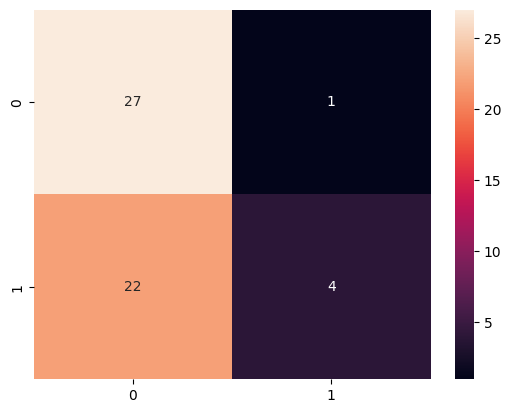

In [87]:
sns.heatmap(cm, annot=True)

In [88]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.55      0.96      0.70        28
           1       0.80      0.15      0.26        26

    accuracy                           0.57        54
   macro avg       0.68      0.56      0.48        54
weighted avg       0.67      0.57      0.49        54

